# **Notebook 3 - Topic Modelling & Perspective Mapping**

This notebook discovers the main discussion themes within YouTube comments related to de-influencing, anti-consumerism and influencer culture.

We compare a traditional topic modelling approach (LDA) with a transformer-based approach (BERTopic). Finally, the discovered topics are interpreted into higher-level consumer perspectives which will later be used by the dashboard and question-answering system.

##Section 1 — Setup & Dependencies

In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import joblib

## Load Dataset

The cleaned dataset produced in the previous notebook is loaded. We use the `light_clean_text` column since it preserves the original meaning while removing unnecessary noise.

In [3]:
df = pd.read_csv("clean_data.csv.gz")

In [4]:
df.head()

,comment_id,video_id,title,author,published_at,like_count,text,light_clean_text,clean_text,word_count,char_count
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:50:06+00:00,0,19:23 expiry dates have left the chat,expiry dates have left the chat,expiry date leave chat,4,22
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:46:57+00:00,0,16:34 just work at a grocery store at this point,just work at a grocery store at this point,work grocery store point,4,24
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sevdalina-e2l,2026-06-22 11:08:51+00:00,0,19:40 this specific content made my heart blee...,this specific content made my heart bleed. Lik...,specific content heart bleed like mean empty k...,10,61
3,UgyrdqXOaEa7C7l8WBd4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sana.On.SunsetAvenue,2026-06-20 21:20:46+00:00,0,"Also, packaging for perishable like milk is li...","Also, packaging for perishable like milk is li...",package perishable like milk create support fr...,14,102
4,UgxfxJBF4IPRIUuSlQl4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Rosie_C,2026-06-20 19:37:36+00:00,0,24:03 I’m a health nut and don’t use anything ...,I’m a health nut and don’t use anything with p...,health nut use paraben sls bring toiletry huma...,11,78


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51807 entries, 0 to 51806
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment_id        51807 non-null  object
 1   video_id          51807 non-null  object
 2   title             51807 non-null  object
 3   author            51807 non-null  object
 4   published_at      51807 non-null  object
 5   like_count        51807 non-null  int64 
 6   text              51807 non-null  object
 7   light_clean_text  51807 non-null  object
 8   clean_text        51807 non-null  object
 9   word_count        51807 non-null  int64 
 10  char_count        51807 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 4.3+ MB


In [6]:
print(df.shape)

(51807, 11)


## Prepare Text

In [7]:
texts = df["light_clean_text"].fillna("").astype(str)

In [8]:
texts = texts[texts.str.strip() != ""]
texts = texts.reset_index(drop=True)

# Part 1 - Latent Dirichlet Allocation (LDA)

LDA is a probabilistic topic modelling algorithm that discovers hidden themes by analysing word co-occurrence patterns across documents.

In [9]:
# Count Vectorizer
vectorizer = CountVectorizer(
    max_features=1000,
    max_df=0.5,
    min_df=5,
    stop_words="english"
)

X = vectorizer.fit_transform(texts)

In [10]:
print(X.shape)

(51807, 1000)


In [11]:
lda = LatentDirichletAllocation(
    n_components=8,
    learning_method="online",
    max_iter=1,
    random_state=42
)

In [12]:
N_ITER = 15
for i in tqdm(range(N_ITER), desc="Training LDA"):
    lda.fit(X)

Training LDA:   0%|          | 0/15 [00:00<?, ?it/s]

## Extract Topics

In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())

In [14]:
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

In [15]:
for topic_idx in range(8):
    print("="*60)
    print(f"Topic {topic_idx}")
    print(feature_names[sorting[topic_idx,:10]])

Topic 0
['consumerism' 'just' 'like' 'social' 'make' 'started' 'media' 'people'
 'society' 'class']
Topic 1
['years' 'collecting' 've' 'year' 'having' 'stuff' 'got' 'bought' 'used'
 'need']
Topic 2
['life' 'just' 'like' 'long' 'really' 'good' 'spending' 'does' 'instead'
 'time']
Topic 3
['collection' 'buy' 'books' 'make' 'just' 'ones' 'new' 'like' 'don'
 'going']
Topic 4
['people' 'money' 'buying' 'think' 'just' 'time' 'don' 'buy' 'really'
 'things']
Topic 5
['feel' 'like' 'use' 'care' 'skin' 'makeup' 'don' 'bag' 'free' 'slavery']
Topic 6
['use' 'hate' 'communism' 'trend' 'need' 'don' 'crap' 'buy' 'america'
 'just']
Topic 7
['like' 'overconsumption' 'people' 'just' 'want' 'stuff' 'lot' 'buy'
 'person' 'dont']


## Assign Topic to Every Comment

In [16]:
document_topics = lda.transform(X)

In [17]:
df = df.loc[texts.index].copy()

In [18]:
df["lda_topic"] = document_topics.argmax(axis=1)

In [19]:
df.head()

,comment_id,video_id,title,author,published_at,like_count,text,light_clean_text,clean_text,word_count,char_count,lda_topic
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:50:06+00:00,0,19:23 expiry dates have left the chat,expiry dates have left the chat,expiry date leave chat,4,22,0
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:46:57+00:00,0,16:34 just work at a grocery store at this point,just work at a grocery store at this point,work grocery store point,4,24,3
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sevdalina-e2l,2026-06-22 11:08:51+00:00,0,19:40 this specific content made my heart blee...,this specific content made my heart bleed. Lik...,specific content heart bleed like mean empty k...,10,61,2
3,UgyrdqXOaEa7C7l8WBd4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sana.On.SunsetAvenue,2026-06-20 21:20:46+00:00,0,"Also, packaging for perishable like milk is li...","Also, packaging for perishable like milk is li...",package perishable like milk create support fr...,14,102,0
4,UgxfxJBF4IPRIUuSlQl4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Rosie_C,2026-06-20 19:37:36+00:00,0,24:03 I’m a health nut and don’t use anything ...,I’m a health nut and don’t use anything with p...,health nut use paraben sls bring toiletry huma...,11,78,5


## Save

In [20]:
joblib.dump(lda,"lda_model.pkl")

joblib.dump(vectorizer,"vectorizer.pkl")

['vectorizer.pkl']

In [21]:
df.to_csv("lda_results.csv",index=False)

# Part 2 - BERTopic
Unlike LDA, BERTopic uses transformer embeddings to capture semantic meaning rather than relying only on word frequency.

In [62]:
df = df[df["light_clean_text"].str.split().str.len() > 3]

In [63]:
# ==========================================================
# BERTopic Perspective Discovery
# ==========================================================

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm

tqdm.pandas(desc="Progress")

print("Loading embedding model...")

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Building BERTopic model...")

topic_model = BERTopic(

    embedding_model=embedding_model,

    language="english",

    calculate_probabilities=True,

    min_topic_size=10,
    nr_topics="auto",

    vectorizer_model=CountVectorizer(
        stop_words="english",
        ngram_range=(1,2)
    ),

    verbose=True
)

print("Training BERTopic...")

topics, probs = topic_model.fit_transform(
    df["light_clean_text"].tolist()
)

print("Finished!")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-07-03 15:23:03,738 - BERTopic - Embedding - Transforming documents to embeddings.


Building BERTopic model...
Training BERTopic...


Batches:   0%|          | 0/1616 [00:00<?, ?it/s]

2026-07-03 15:23:46,921 - BERTopic - Embedding - Completed ✓
2026-07-03 15:23:46,923 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-03 15:24:48,157 - BERTopic - Dimensionality - Completed ✓
2026-07-03 15:24:48,160 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 15:33:51,807 - BERTopic - Cluster - Completed ✓
2026-07-03 15:33:51,809 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-07-03 15:34:00,154 - BERTopic - Representation - Completed ✓
2026-07-03 15:34:00,176 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 15:34:00,512 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 15:34:08,364 - BERTopic - Representation - Completed ✓
2026-07-03 15:34:08,393 - BERTopic - Topic reduction - Reduced number of topics from 431 to 338


Finished!


In [64]:
topic_model = topic_model.reduce_outliers(
    df["light_clean_text"].tolist(),
    topics,
    strategy="embeddings"
)

## Save results

In [65]:
df["topic"] = topics

df.to_csv(
    "bertopic_results.csv",
    index=False
)

## Topic Summary

In [76]:
# The `topic_model` variable has been inadvertently overwritten as a list.
# Re-load the BERTopic model to restore its functionality.
from bertopic import BERTopic
topic_model = BERTopic.load("bertopic_model")

topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32844,-1_like_just_people_don,"[like, just, people, don, things, need, buy, u...",[The thing that’s a shame in the first modern ...
1,0,12045,0_like_just_fridge_don,"[like, just, fridge, don, books, buy, people, ...",[There are a lot of people who do that. Hand s...
2,1,1654,1_ice_cubes_trays_ice cubes,"[ice, cubes, trays, ice cubes, cube, ice cube,...",[I have autism and with it comes a condition c...
3,2,409,2_slavery_slave_slaves_consumerism,"[slavery, slave, slaves, consumerism, perfecti...","[Actually, Slavery is the perfection of Slaver..."
4,3,350,3_razor_razors_shower_wall,"[razor, razors, shower, wall, razor corner, co...","[The razor corner took me out 😮😢😭, The razor c..."
5,4,329,4_plastic_beaded bags_beaded_bags,"[plastic, beaded bags, beaded, bags, waste, pl...","[Those beaded bags were so ugly, Those beaded ..."
6,5,290,5_nails_tapping_nail_fingernails,"[nails, tapping, nail, fingernails, nail tappi...",[How do they do anything with those ridiculous...
7,6,264,6_batteries_battery_organizer_battery organizer,"[batteries, battery, organizer, battery organi...",[That's a very small battery organizer in the ...
8,7,241,7_sleep_bed_morning_hair,"[sleep, bed, morning, hair, morning shed, shed...",[Want to drop a comment as a new user of those...
9,8,228,8_store_storage_storage unit_unit,"[store, storage, storage unit, unit, grocery, ...","[""Shopping her storage unit"" someone with a wh..."


## Save topic table

In [77]:
topic_info.to_csv(
    "topic_summary.csv",
    index=False
)

## Top words per topic

In [78]:
for topic in topic_info.Topic:

    if topic == -1:
        continue

    print("="*70)
    print("Topic", topic)
    print(topic_model.get_topic(topic))

Topic 0
[('like', np.float64(0.009299533932687645)), ('just', np.float64(0.008041102795956644)), ('fridge', np.float64(0.007637244569861998)), ('don', np.float64(0.007616339840034693)), ('books', np.float64(0.007297731289324352)), ('buy', np.float64(0.007069930000735334)), ('people', np.float64(0.006932491659597828)), ('use', np.float64(0.006463388923761953)), ('love', np.float64(0.006170442516602984)), ('things', np.float64(0.005876825665712528))]
Topic 1
[('ice', np.float64(0.08342506361463552)), ('cubes', np.float64(0.01821815428291718)), ('trays', np.float64(0.016420417160349247)), ('ice cubes', np.float64(0.016207478014848)), ('cube', np.float64(0.012892028982777016)), ('ice cube', np.float64(0.011743749680478047)), ('freezer', np.float64(0.011613995354146818)), ('like', np.float64(0.011453015769924128)), ('ice trays', np.float64(0.010576102141915487)), ('coffee', np.float64(0.010208929441083026))]
Topic 2
[('slavery', np.float64(0.08375381983696878)), ('slave', np.float64(0.03438

## Interactive Visualizations

In [79]:
# Topic hierarchy
topic_model.visualize_hierarchy()

In [80]:
# Topic bar chart
topic_model.visualize_barchart(top_n_topics=15)

In [81]:
# Topic similarity heatmap
topic_model.visualize_heatmap()

In [82]:
num_non_outlier_topics = len(topic_model.get_topics()) - 1

if num_non_outlier_topics > 2:
    # Inter-topic distance map
    topic_model.visualize_topics()
else:
    print(f"Skipping inter-topic distance map visualization: Only {num_non_outlier_topics} non-outlier topics found. At least 3 are recommended for meaningful visualization.")

In [83]:
# Topic frequency
topic_model.visualize_term_rank()

In [84]:
# Find similar topics
similar_topics, similarity = topic_model.find_topics(
    "consumerism",
    top_n=5
)

print(similar_topics)
print(similarity)

[8, 46, 31, 53, 10]
[np.float64(0.4687662600958682), np.float64(0.43484136888415226), np.float64(0.4217706596873575), np.float64(0.2822080294117116), np.float64(0.265863240087033)]


## Save the trained model

In [85]:
topic_model.save("bertopic_model")

2026-07-03 15:36:21,985 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


## LDA vs BERTopic

The transformer-based model generally produces more coherent and semantically meaningful topics compared to the frequency-based LDA approach.

In [86]:
print("LDA Topics")

print(df["lda_topic"].value_counts())

print()

print("BERTopic Topics")

print(df["topic"].value_counts())

LDA Topics
lda_topic
0    10377
4     9470
7     8107
5     6101
1     5942
3     5330
2     3827
6     2530
Name: count, dtype: int64

BERTopic Topics
topic
-1      22184
 0       1788
 1       1302
 2       1085
 3        995
        ...  
 332       10
 333       10
 334       10
 335       10
 336       10
Name: count, Length: 338, dtype: int64


# Part 3 - Perspective Mapping

After inspecting the discovered BERTopic topics, each topic is manually assigned to a broader consumer perspective. This creates interpretable business categories rather than anonymous topic numbers.

In [87]:
# Inspect topics
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,32844,-1_like_just_people_don,"[like, just, people, don, things, need, buy, u...",[The thing that’s a shame in the first modern ...
1,0,12045,0_like_just_fridge_don,"[like, just, fridge, don, books, buy, people, ...",[There are a lot of people who do that. Hand s...
2,1,1654,1_ice_cubes_trays_ice cubes,"[ice, cubes, trays, ice cubes, cube, ice cube,...",[I have autism and with it comes a condition c...
3,2,409,2_slavery_slave_slaves_consumerism,"[slavery, slave, slaves, consumerism, perfecti...","[Actually, Slavery is the perfection of Slaver..."
4,3,350,3_razor_razors_shower_wall,"[razor, razors, shower, wall, razor corner, co...","[The razor corner took me out 😮😢😭, The razor c..."
5,4,329,4_plastic_beaded bags_beaded_bags,"[plastic, beaded bags, beaded, bags, waste, pl...","[Those beaded bags were so ugly, Those beaded ..."
6,5,290,5_nails_tapping_nail_fingernails,"[nails, tapping, nail, fingernails, nail tappi...",[How do they do anything with those ridiculous...
7,6,264,6_batteries_battery_organizer_battery organizer,"[batteries, battery, organizer, battery organi...",[That's a very small battery organizer in the ...
8,7,241,7_sleep_bed_morning_hair,"[sleep, bed, morning, hair, morning shed, shed...",[Want to drop a comment as a new user of those...
9,8,228,8_store_storage_storage unit_unit,"[store, storage, storage unit, unit, grocery, ...","[""Shopping her storage unit"" someone with a wh..."


In [90]:
# Load Model and topics
from bertopic import BERTopic
import pandas as pd

# Load model (you already saved it)
topic_model = BERTopic.load("bertopic_model")

# Load data
df = pd.read_csv("bertopic_results.csv")

In [91]:
# get topic keywords
topic_words = {}

for topic_id in topic_model.get_topics().keys():
    if topic_id == -1:
        continue

    words = [word for word, _ in topic_model.get_topic(topic_id)]
    topic_words[topic_id] = words

In [92]:
# Perspective Mapping logic
def map_perspective(words):

    w = " ".join(words).lower()

    # 1. Outliers / Noise
    if any(x in w for x in ["blah", "random", "lol", "comment"]):
        return "Outlier / Noise"

    # 2. Everyday Objects & Consumption
    if any(x in w for x in ["fridge", "store", "grocery", "bottle", "bag", "jar", "battery", "coffee", "ice"]):
        return "Everyday Objects & Consumption"

    # 3. Beauty / Self-presentation
    if any(x in w for x in ["hair", "skin", "makeup", "blush", "skincare", "nails", "beauty"]):
        return "Beauty & Self-Presentation"

    # 4. Consumerism / Material critique
    if any(x in w for x in ["plastic", "waste", "landfill", "debt", "credit", "money", "sephora", "buy", "haul"]):
        return "Consumerism & Material Culture"

    # 5. Social / Identity / Culture
    if any(x in w for x in ["school", "teacher", "student", "friend", "vegan", "china", "america", "brazil"]):
        return "Social Life & Identity"

    # 6. Society / Power / Systems
    if any(x in w for x in ["slavery", "system", "government", "ceo", "economy", "power", "freedom"]):
        return "Society, Economy & Power Systems"

    # 7. Health / Body / Routine
    if any(x in w for x in ["sleep", "shower", "routine", "health", "nurse", "medicine", "steps"]):
        return "Health, Routine & Physical Behavior"

    # 8. Abstract / Meme / Philosophical
    if any(x in w for x in ["god", "jesus", "patrick bateman", "ergo", "cogito", "meme", "funny"]):
        return "Abstract / Meme / Philosophical"

    # 9. Digital / Pop culture
    if any(x in w for x in ["video", "series", "james charles", "cyber", "content"]):
        return "Digital Media & Pop Culture"

    return "Other"

In [93]:
# topic --> Perspective map
topic_to_perspective = {}

for topic_id, words in topic_words.items():
    topic_to_perspective[topic_id] = map_perspective(words)

In [94]:
# apply to dataframe
def get_perspective(topic_id):
    if topic_id == -1:
        return "Outlier / Noise"
    return topic_to_perspective.get(topic_id, "Other")

df["perspective"] = df["topic"].apply(get_perspective)

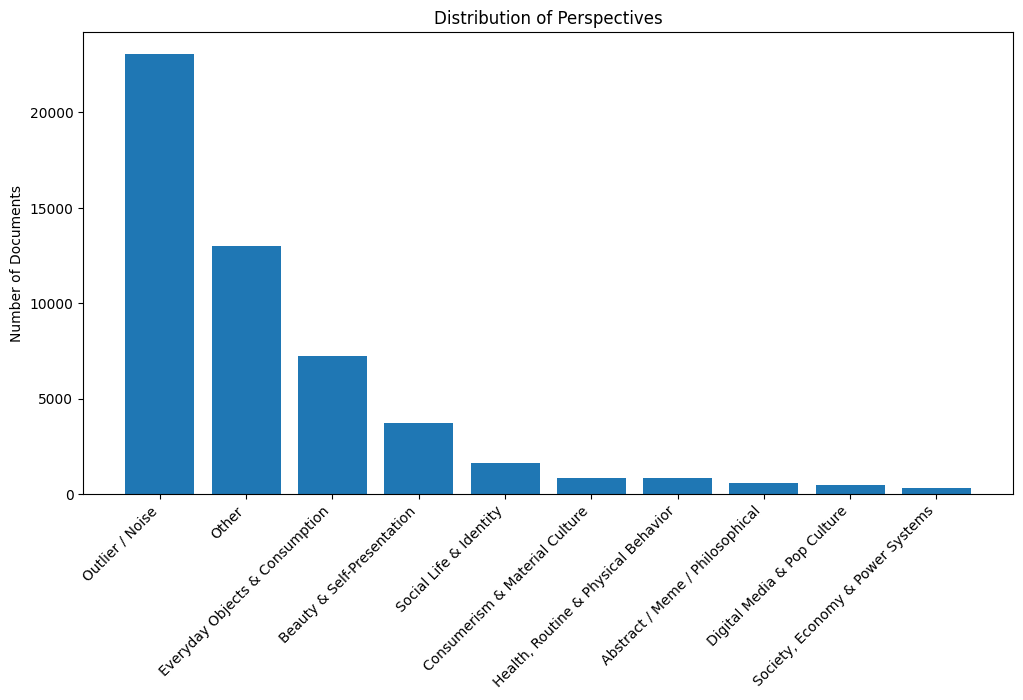

In [95]:
# Distribution
import matplotlib.pyplot as plt

counts = df["perspective"].value_counts()

plt.figure(figsize=(12,6))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Perspectives")
plt.ylabel("Number of Documents")
plt.show()

In [96]:
print(counts)

perspective
Outlier / Noise                        23064
Other                                  12997
Everyday Objects & Consumption          7257
Beauty & Self-Presentation              3722
Social Life & Identity                  1622
Consumerism & Material Culture           850
Health, Routine & Physical Behavior      811
Abstract / Meme / Philosophical          573
Digital Media & Pop Culture              460
Society, Economy & Power Systems         328
Name: count, dtype: int64


# Summary

In this notebook, two topic modelling approaches were explored.

LDA provided a traditional statistical baseline, while BERTopic generated more semantically meaningful topics using transformer embeddings.

The discovered topics were further grouped into consumer perspectives that will be used by the sentiment analysis, dashboard and RAG-based question answering system in the following notebooks.

Limitation: A significant portion of documents were classified as outliers due to the short and noisy nature of user-generated content. However, BERTopic successfully identified coherent semantic perspectives such as consumption behavior, beauty practices, and social identity discussions, which form the main analytical focus of this study

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [100]:
topic_model.save("/content/drive/MyDrive/bertopic_model")

2026-07-03 15:57:56,721 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [101]:
df.to_csv("/content/drive/MyDrive/bertopic_with_perspectives.csv", index=False)